In [ ]:
#| default_exp models.ml_mv_forecaster

In [ ]:
#| export

# from nbdev.showdoc import *
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
from sklearn.base import clone
from tabnanny import verbose
import numpy as np
import pandas as pd
import copy
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform, undiff_ts, seasonal_diff,
                        invert_seasonal_diff, kfold_target_encoder, target_encoder_for_test,
                        rolling_quantile, rolling_mean, rolling_std,
                        expanding_mean, expanding_std, expanding_quantile)
from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
from peshbeen.formatting import make_main_gt, gt_mini, inject_header_table_groups, cov_table, make_var_gt_regimes
from catboost import CatBoostRegressor
from cubist import Cubist
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")
import copy
import statsmodels.api as sm
from scipy.stats import norm, multivariate_normal
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.special import logsumexp
from scipy.stats import t
import re # for regex escaping to build drop patterns

class ml_mv_forecaster:
    def __init__(
        self,
        model: Any, # e.g. LGBMRegressor(), CatBoostRegressor(), LinearRegression(), etc.
        target_cols: List[str], # list of target variable names
        lags: Optional[Dict[str, Union[int, List[int]]]] = None, # Dictionary of lags per target, e.g. {'y1': 3, 'y2': [1, 2, 4]}
        lag_transform: Optional[Dict[str, list]] = None, # Lag transform functions per target, e.g. {'y1': [expanding_mean(3)], 'y2': [rolling_std(5)]}
        difference: Optional[Dict[str, int]] = None, # Ordinary differencing order per target, e.g. {'y1': 1, 'y2': 1}
        seasonal_diff: Optional[Dict[str, int]] = None, # Seasonal differencing order per target, e.g. {'y1': 12, 'y2': 7}
        trend: Optional[Dict[str, str]] = None, # Trend strategies per target, e.g. {'y1': 'linear', 'y2': 'ets'}
        pol_degree: Optional[Union[int, Dict[str, int]]] = 1, # Polynomial degree for linear trend per target, e.g. 1 or {'y1': 1, 'y2': 2}
        ets_params: Optional[Dict[str, tuple]] = None, # ETS model/fit params per target, e.g. {'y1': ({'trend': 'add'}, {'damped_trend': True}), 'y2': ({'trend': 'mul'}, {})}
        change_points: Optional[Dict[str, List[int]]] = None, # Change points for piecewise linear trend per target, e.g. {'y1': [100, 200], 'y2': [150]}
        box_cox: Optional[Dict[str, bool]] = None, # Whether to apply Box-Cox per target, e.g. {'y1': True, 'y2': False}
        box_cox_lmda: Optional[Dict[str, float]] = None, # Box-Cox lambda per target, e.g. {'y1': 0.5, 'y2': None}
        box_cox_biasadj: Optional[Dict[str, bool]] = None, # Bias adjustment after inverting Box-Cox per target, e.g. {'y1': True, 'y2': False}
        cat_variables: Optional[List[str]] = None, # categorical feature columns (shared across targets)
        target_encode: bool = False, # whether to use target encoding instead of one-hot encoding (shared across targets)
    ) -> None:
        
        """"
        Initialize the multi-target machine learning forecaster with specified transformations and model.

        Parameters
        ----------
        model : Any
            A scikit-learn compatible regression model instance (e.g. LGBMRegressor(), CatBoostRegressor(), LinearRegression(), etc.).
        target_cols : List[str]
            List of target variable names to forecast.
        lags : Optional[Dict[str, Union[int, List[int]]]], optional
            Dictionary specifying lag features to create for each target variable. The value can be an integer (number of lags) or a list of specific lag periods.
        lag_transform : Optional[Dict[str, list]], optional
            Dictionary specifying lag-based transformations to apply for each target variable. The value should be a list of transformation functions (e.g. rolling_mean, expanding_std) with their parameters encapsulated in the function instance.
        difference : Optional[Dict[str, int]], optional
            Dictionary specifying the order of ordinary differencing to apply for each target variable.
        seasonal_diff : Optional[Dict[str, int]], optional
            Dictionary specifying the order of seasonal differencing to apply for each target variable.
        trend : Optional[Dict[str, str]], optional
            Dictionary specifying the trend removal strategy for each target variable. Supported values are 'linear', 'ets', 'feature_lr', and 'feature_ets'.
        pol_degree : Optional[Union[int, Dict[str, int]]], optional
            Polynomial degree for linear trend removal. Can be a single integer applied to all targets or a dictionary specifying the degree for each target variable.
        ets_params : Optional[Dict[str, tuple]], optional
            Dictionary specifying ETS model and fit parameters for each target variable when using 'ets' or 'feature_ets' trend removal. The value should be a tuple of (model_params, fit_params) where model_params are passed to ExponentialSmoothing and fit_params are passed to the fit() method.
        change_points : Optional[Dict[str, List[int]]], optional
            Dictionary specifying change points for piecewise linear trend removal for each target variable. The value should be a list of integer indices where the trend slope can change.
        box_cox : Optional[Dict[str, bool]], optional
            Dictionary specifying whether to apply Box-Cox transformation for each target variable.
        box_cox_lmda : Optional[Dict[str, float]], optional
            Dictionary specifying the lambda parameter for Box-Cox transformation for each target variable. If not provided, lambda will be estimated from the data.
        box_cox_biasadj : Optional[Dict[str, bool]], optional
            Dictionary specifying whether to apply bias adjustment when inverting Box-Cox transformation for each target variable.
        cat_variables : Optional[List[str]], optional
            List of categorical feature column names to encode. These will be shared across all target variables.
        target_encode : bool, optional
            Whether to use target encoding for categorical variables instead of one-hot encoding. If True, the categorical variables will be encoded based on the mean of the first target variable in target_cols. This is only applicable if cat_variables is provided. If False, one-hot encoding will be applied for non-native
        
        Returns
        -------
        None
        """

        self.model = model
        self.target_cols = target_cols
        self.cat_variables = cat_variables
        self.target_encode = target_encode
        self.ets_params = ets_params
        self.cps = change_points

        # ── lags ──────────────────────────────────────────────────────────────
        self.n_lag = {}
        if lags is not None:
            if not isinstance(lags, dict):
                raise TypeError("lags must be a dict keyed by target column name.")
            for col, v in lags.items():
                if isinstance(v, int):
                    self.n_lag[col] = list(range(1, v + 1))
                elif isinstance(v, list):
                    self.n_lag[col] = v
                else:
                    raise TypeError(f"lags['{col}'] must be int or list of ints.")

        # ── lag_transform ─────────────────────────────────────────────────────
        if lag_transform is not None:
            if not isinstance(lag_transform, dict):
                raise TypeError("lag_transform must be a dict keyed by target column name.")
            self.lag_transform = lag_transform
        else:
            self.lag_transform = None

        # ── differencing ──────────────────────────────────────────────────────
        self.diffs = {col: None for col in target_cols}
        if difference is not None:
            if not isinstance(difference, dict):
                raise TypeError("difference must be a dict keyed by target column name.")
            self.diffs.update(difference)

        # ── seasonal differencing ─────────────────────────────────────────────
        self.season_diffs = {col: None for col in target_cols}
        if seasonal_diff is not None:
            if not isinstance(seasonal_diff, dict):
                raise TypeError("seasonal_diff must be a dict keyed by target column name.")
            self.season_diffs.update(seasonal_diff)

        # ── trend ─────────────────────────────────────────────────────────────
        self.trend = trend
        if trend is not None and not isinstance(trend, dict):
            raise TypeError("trend must be a dict keyed by target column name.")

        # ── polynomial degree ─────────────────────────────────────────────────
        if isinstance(pol_degree, int):
            self.pol = {col: pol_degree for col in target_cols}
        elif isinstance(pol_degree, dict):
            self.pol = {col: pol_degree.get(col, 1) for col in target_cols}
        else:
            raise ValueError("pol_degree must be an int or a dict.")

        # ── box-cox ───────────────────────────────────────────────────────────
        self.box_cox = {col: False for col in target_cols}
        if box_cox is not None:
            if not isinstance(box_cox, dict):
                raise TypeError("box_cox must be a dict keyed by target column name.")
            self.box_cox.update(box_cox)

        self.lamdas = {col: None for col in target_cols}
        if box_cox_lmda is not None:
            if not isinstance(box_cox_lmda, dict):
                raise TypeError("box_cox_lmda must be a dict keyed by target column name.")
            self.lamdas.update(box_cox_lmda)

        self.biasadj = {col: False for col in target_cols}
        if box_cox_biasadj is not None:
            if not isinstance(box_cox_biasadj, dict):
                raise TypeError("box_cox_biasadj must be a dict keyed by target column name.")
            self.biasadj.update(box_cox_biasadj)

        # ── placeholders set during fit ───────────────────────────────────────
        self.model_fits: Dict[str, Any] = {}
        self.y_dict: Dict[str, pd.Series] = {}

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────

    def data_prep(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Apply all preprocessing transformations to df and return the cleaned DataFrame.
        """
        dfc = df.copy()

        # ── categorical encoding ──────────────────────────────────────────────
        if self.cat_variables is not None:
            if self.target_encode:
                # Target encoding: use first target for encoding reference
                for col in self.cat_variables:
                    encode_col = col + "_target_encoded"
                    dfc[encode_col] = kfold_target_encoder(dfc, col, self.target_cols[0], 36)
                self.df_encode = dfc.copy()
                dfc = dfc.drop(columns=self.cat_variables)
            else:
                if isinstance(self.model, (LGBMRegressor, CatBoostRegressor)):
                    for col in self.cat_variables:
                        dfc[col] = dfc[col].astype('category')
                else:
                    for col, cats in self.cat_var.items():
                        dfc[col] = pd.Categorical(dfc[col], categories=cats)
                    dfc = pd.get_dummies(dfc, dtype=float)
                    if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
                        for pat in self.drop_categ_patterns:
                            cols = list(dfc.filter(regex=pat).columns)
                            if cols:
                                dfc.drop(cols, axis=1, inplace=True)

        if not all(col in dfc.columns for col in self.target_cols):
            return dfc.dropna()

        # ── Box-Cox ───────────────────────────────────────────────────────────
        self.is_zeros: Dict[str, bool] = {} # track if shift was applied for each target
        for col in self.target_cols:
            if self.box_cox.get(col, False):
                self.is_zeros[col] = (dfc[col] < 1).any()
                trans_data, self.lamdas[col] = box_cox_transform(
                    x=dfc[col], shift=self.is_zeros[col], box_cox_lmda=self.lamdas[col]
                ) # returns transformed data and lambda. If lambda is not provided, it is estimated from the data.
                dfc[col] = trans_data

        # ── Trend removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.orig_targets: Dict[str, pd.Series] = {}
            self.trend_models: Dict[str, Any] = {}
            self.X_trend_forecasts: Dict[str, np.ndarray] = {}  # for feature_lr

            for col, ttype in self.trend.items():
                self.orig_targets[col] = dfc[col].copy()

                if ttype in ("linear", "feature_lr"):
                    bps = self.cps.get(col) if self.cps else None
                    if bps:
                        trend_vals, model_fit, X_trend = lr_trend_model(
                            self.orig_targets[col], degree=self.pol[col],
                            breakpoints=bps, type='piecewise'
                        )
                    else:
                        trend_vals, model_fit, X_trend = lr_trend_model(
                            self.orig_targets[col], degree=self.pol[col])
                    self.trend_models[col] = (model_fit, X_trend)
                    if ttype == "linear":
                        dfc[col] = dfc[col] - trend_vals

                elif ttype in ("ets", "feature_ets"):
                    ep = self.ets_params[col]
                    model_fit = ExponentialSmoothing(self.orig_targets[col], **ep[0]).fit(**ep[1])
                    self.trend_models[col] = model_fit
                    if ttype == "ets":
                        dfc[col] = dfc[col] - model_fit.fittedvalues.values

                else:
                    raise ValueError(
                        f"Unknown trend type '{ttype}' for '{col}'. "
                        "Use 'linear', 'ets', 'feature_lr', or 'feature_ets'."
                    )

        # ── Ordinary differencing ─────────────────────────────────────────────
        self.origs: Dict[str, list] = {}
        for col, d in self.diffs.items():
            if d is not None:
                self.origs[col] = dfc[col].tolist()
                dfc[col] = np.diff(dfc[col], n=d, prepend=np.repeat(np.nan, d))

        # ── Seasonal differencing ─────────────────────────────────────────────
        self.orig_ds: Dict[str, list] = {}
        for col, s in self.season_diffs.items():
            if s is not None:
                self.orig_ds[col] = dfc[col].tolist()
                dfc[col] = seasonal_diff(dfc[col], s)

        # ── Lag features ──────────────────────────────────────────────────────
        for col, lags in self.n_lag.items():
            for lg in lags:
                dfc[f"{col}_lag_{lg}"] = dfc[col].shift(lg)

        # ── Lag transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for idx, (col, funcs) in enumerate(self.lag_transform.items()):
                for func in funcs:
                    if isinstance(func, (expanding_std, expanding_mean)):
                        dfc[f"trg{idx}_{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[col])
                    elif isinstance(func, expanding_quantile):
                        dfc[f"trg{idx}_{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[col])
                    elif isinstance(func, rolling_quantile):
                        dfc[f"trg{idx}_{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[col])
                    else:
                        dfc[f"trg{idx}_{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[col])

        # ── Trend as features ─────────────────────────────────────────────────
        if self.trend is not None:
            for col, ttype in self.trend.items():
                if ttype == "feature_lr":
                    model_fit, X_trend = self.trend_models[col]
                    for i in range(X_trend.shape[1]):
                        dfc[f"trend_{col}_{i}"] = X_trend[:, i]
                elif ttype == "feature_ets":
                    dfc[f"trend_{col}"] = self.trend_models[col].fittedvalues.values

        return dfc.dropna()

    # ─────────────────────────────────────────────────────────────────────────
    # FIT
    # ─────────────────────────────────────────────────────────────────────────

    def fit(self,
            df: pd.DataFrame
            ) -> None:
        
        """
        Fit the model to the data passed in df

        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing all target and feature columns.

        Returns
        -------
        None
        """
        # Build categorical lookup for non-native-cat models
        if isinstance(self.model, (
            XGBRegressor, RandomForestRegressor, Cubist,
            HistGradientBoostingRegressor, AdaBoostRegressor,
            LinearRegression, Ridge, Lasso, ElasticNet)):
            if self.cat_variables is not None and not self.target_encode:
                self.cat_var = {
                    c: sorted(df[c].drop_duplicates().tolist())
                    for c in self.cat_variables
                }
                if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
                    self.drop_categ_patterns = []
                    for c in self.cat_variables:
                        base = sorted(df[c].drop_duplicates().tolist())[0]
                        self.drop_categ_patterns.append(rf"^{re.escape(c)}_{re.escape(str(base))}$")

        model_df = self.data_prep(df)
        X = model_df.drop(columns=self.target_cols)
        self.X = X  # store feature matrix for AIC/BIC properties

        for col in self.target_cols:
            y = model_df[col]
            self.y_dict[col] = y
            m = clone(self.model)

            if isinstance(self.model, CatBoostRegressor):
                self.model_fits[col] = m.fit(X, y, cat_features=self.cat_variables, verbose=False)
            elif isinstance(self.model, LGBMRegressor):
                self.model_fits[col] = m.fit(X, y, categorical_feature=self.cat_variables)
            else:
                self.model_fits[col] = m.fit(X, y)

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────

    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None
    ) -> Dict[str, np.ndarray]:
        
        """
        Generate forecasts for H future time steps.

        Parameters
        ----------
        H : int
            Forecast horizon (number of steps to forecast ahead).
        exog : Optional[pd.DataFrame], optional
            Future exogenous regressors (must contain at least H rows).
            
        Returns
        -------
        Dict[str, np.ndarray]
            A dictionary where keys are target column names and values are arrays of H forecasted values for each target variable.
        """

        # Prepare exog if provided
        if exog is not None:
            if self.cat_variables is not None and not self.target_encode:
                if isinstance(self.model, (
                    XGBRegressor, RandomForestRegressor, Cubist,
                    HistGradientBoostingRegressor, AdaBoostRegressor,
                    LinearRegression, Ridge, Lasso, ElasticNet
                )):
                    exog = self.data_prep(exog)
            elif self.cat_variables is not None and self.target_encode:
                for col in self.cat_variables:
                    encode_col = col + "_target_encoded"
                    exog[encode_col] = target_encoder_for_test(self.df_encode, exog, col)
                exog = exog.drop(columns=self.cat_variables)

        # Rolling history for each target (used to build lag features recursively)
        y_lists: Dict[str, list] = {col: self.y_dict[col].tolist() for col in self.target_cols}

        # ── Pre-compute trend forecasts ───────────────────────────────────────
        trend_forecasts: Dict[str, np.ndarray] = {}
        X_trend_forecasts: Dict[str, np.ndarray] = {}

        if self.trend is not None:
            for col, ttype in self.trend.items():
                if ttype in ("linear", "feature_lr"):
                    model_fit, _ = self.trend_models[col]
                    bps = self.cps.get(col) if self.cps else None
                    tf, X_tf = forecast_trend(
                        model=model_fit, H=H, start=self.len,
                        degree=self.pol[col], breakpoints=bps
                    )
                    trend_forecasts[col] = tf
                    X_trend_forecasts[col] = X_tf
                elif ttype in ("ets", "feature_ets"):
                    trend_forecasts[col] = np.array(self.trend_models[col].forecast(H))

        # ── Recursive forecast loop ───────────────────────────────────────────
        raw_forecasts: Dict[str, list] = {col: [] for col in self.target_cols}

        for t in range(H):
            # Exogenous features for step t
            x_var = exog.iloc[t, :].tolist() if exog is not None else []

            # Lag features
            inp_lag = []
            for col, lags in self.n_lag.items():
                inp_lag.extend([y_lists[col][-lg] for lg in lags])

            # Lag-transform features
            transform_lag = []
            if self.lag_transform is not None:
                for col, funcs in self.lag_transform.items():
                    series_array = np.array(y_lists[col])
                    for func in funcs:
                        transform_lag.append(func(series_array, is_forecast=True).to_numpy()[-1])

            # Trend features (feature_lr / feature_ets only)
            trend_var = []
            if self.trend is not None:
                for col, ttype in self.trend.items():
                    if ttype == "feature_lr":
                        trend_var.extend(X_trend_forecasts[col][t, :].tolist())
                    elif ttype == "feature_ets":
                        trend_var.append(trend_forecasts[col][t])

            inp = x_var + inp_lag + transform_lag + trend_var
            df_inp = pd.DataFrame(np.array(inp).reshape(1, -1), columns=self.X.columns)

            if isinstance(self.model, (LGBMRegressor, CatBoostRegressor)):
                for c in df_inp.columns:
                    if c in (self.cat_variables or []):
                        df_inp[c] = df_inp[c].astype(int).astype('category')
                    else:
                        df_inp[c] = df_inp[c].astype('float64')

            # Predict each target and update its rolling history
            for col in self.target_cols:
                pred = self.model_fits[col].predict(df_inp)[0]
                raw_forecasts[col].append(pred)
                y_lists[col].append(pred)

        # ── Post-processing (mirrors VARModel.forecast) ───────────────────────
        forecasts: Dict[str, np.ndarray] = {col: np.array(raw_forecasts[col]) for col in self.target_cols}

        # Add back removed trend
        if self.trend is not None:
            for col, ttype in self.trend.items():
                if ttype in ("linear", "ets"):
                    forecasts[col] = forecasts[col] + trend_forecasts[col]

        # Invert seasonal differencing
        for col, s in self.season_diffs.items():
            if s is not None:
                forecasts[col] = invert_seasonal_diff(self.orig_ds[col], forecasts[col], s)

        # Invert ordinary differencing
        for col, d in self.diffs.items():
            if d is not None:
                forecasts[col] = undiff_ts(self.origs[col], forecasts[col], d)

        # Non-negativity
        for col in forecasts:
            forecasts[col] = np.array([max(0, x) for x in forecasts[col]])

        # Invert Box-Cox
        for col in self.target_cols:
            if self.box_cox.get(col, False):
                forecasts[col] = back_box_cox_transform(
                    y_pred=forecasts[col],
                    lmda=self.lamdas[col],
                    shift=self.is_zeros.get(col, False),
                    box_cox_biasadj=self.biasadj[col]
                )

        return forecasts

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA  (mirrors ml_forecaster AIC/BIC properties)
    # ─────────────────────────────────────────────────────────────────────────

    def _k(self) -> int:
        """Number of model parameters (approximate)."""
        base = self.X.shape[1]
        if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            return base + 2   # coefficients + intercept + variance
        return base + 1       # coefficients + variance

    def _ic_base(self, col: str):
        k = self._k()
        n = len(self.y_dict[col])
        rss = np.sum((self.y_dict[col].to_numpy() - self.model_fits[col].predict(self.X)) ** 2)
        return k, n, rss

    @property
    def aic(self) -> Dict[str, float]:
        """AIC per target variable."""
        out = {}
        for col in self.target_cols:
            k, n, rss = self._ic_base(col)
            out[col] = n * np.log(rss / n) + 2 * k
        return out

    @property
    def aicc(self) -> Dict[str, float]:
        """AICc per target variable."""
        out = {}
        for col in self.target_cols:
            k, n, rss = self._ic_base(col)
            aic = n * np.log(rss / n) + 2 * k
            out[col] = aic + (2 * k * (k + 1)) / (n - k - 1)
        return out

    @property
    def bic(self) -> Dict[str, float]:
        """BIC per target variable."""
        out = {}
        for col in self.target_cols:
            k, n, rss = self._ic_base(col)
            out[col] = n * np.log(rss / n) + k * np.log(n)
        return out

    @property
    def hqc(self) -> Dict[str, float]:
        """Hannan-Quinn criterion per target variable."""
        out = {}
        for col in self.target_cols:
            k, n, rss = self._ic_base(col)
            out[col] = n * np.log(rss / n) + 2 * k * np.log(np.log(n))
        return out

    def copy(self):
        return copy.deepcopy(self)

    def cross_validate(self,
                       df: pd.DataFrame,
                       target_col: str,
                       cv_split: int,
                       test_size: int,
                       metrics: List[Callable],
                       step_size: int = 1,
                       h_split_point: Optional[int] = None,
                       cv_df = False
                       ) -> Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]:
        """
        Perform cross-validation.

        Parameters
        ----------
        df : pd.DataFrame
            Input dataframe.
        target_col : str
            Target variable for evaluation.
        cv_split : int
            Number of cross-validation folds.
        test_size : int
            Test size per fold.
        metrics : List[Callable]
            List of metric functions.
        step_size : int, optional
            Step size for rolling window. Default is 1.
        h_split_point : int, optional
            Point to split the test set for separate evaluation. Default is None.
        cv_df : bool, optional
            Whether to return the cross-validation dataframe. If True, also returns a DataFrame with forecasts and actuals for each fold.
    
        Returns
        -------
        pd.DataFrame
            DataFrame with overall performance metrics averaged across folds. If h_split_point is provided, also includes separate performance before and after the split point.
        """

        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}

        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test, y_test = test.drop(columns=self.target_cols), np.array(test[target_col])
            self.fit(train)
            forecasts = self.forecast(test_size, x_test)[target_col]

            for m in metrics:
                if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                    eval_val = m(y_test, forecasts, train[target_col])
                else:
                    eval_val = m(y_test, forecasts)
                metrics_dict[m.__name__].append(eval_val)
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point], y_test[h_split_point:]
                bb_forecast_1, bb_forecast_2 = forecasts[:h_split_point], forecasts[h_split_point:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_cols]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_cols]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)

            if cv_df:
                ## store results for this split
                all_forecasts = self.forecast(test_size, x_test)
                actuals = {f"actual_{col}": test[col].values for col in self.target_cols}
                all_forecasts_dict = {f"forecast_{col}": all_forecasts[col] for col in self.target_cols}
                split_results = {"cutoff": np.repeat(test.index[0], len(test)), "index": test.index,
                                "split": np.repeat(f"fold_{idx+1}", len(test))}
                
                split_results.update(actuals)
                split_results.update(all_forecasts_dict)

                cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)
                
        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"score_before_{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"score_after_{h_split_point}"})
            # merge all three dataframes
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")
        return overall_performance, cv_df_


In [ ]:
#| hide
from fastcore.docments import docments, DocmentTbl
from nbdev.showdoc import *

In [ ]:
#| echo: false
docments(ml_mv_forecaster, full=True) # show full docstring in docs, not just signature
DocmentTbl(ml_mv_forecaster)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| model | Any |  | e.g. LGBMRegressor(), CatBoostRegressor(), LinearRegression(), etc. |
| target_cols | List[str] |  | list of target variable names |
| lags | Optional[Dict[str, Union[int, List[int]]]] | None | Dictionary of lags per target, e.g. {'y1': 3, 'y2': [1, 2, 4]} |
| lag_transform | Optional[Dict[str, list]] | None | Lag transform functions per target, e.g. {'y1': [expanding_mean(3)], 'y2': [rolling_std(5)]} |
| difference | Optional[Dict[str, int]] | None | Ordinary differencing order per target, e.g. {'y1': 1, 'y2': 1} |
| seasonal_diff | Optional[Dict[str, int]] | None | Seasonal differencing order per target, e.g. {'y1': 12, 'y2': 7} |
| trend | Optional[Dict[str, str]] | None | Trend strategies per target, e.g. {'y1': 'linear', 'y2': 'ets'} |
| pol_degree | Optional[Union[int, Dict[str, int]]] | 1 | Polynomial degree for linear trend per target, e.g. 1 or {'y1': 1, 'y2': 2} |
| ets_params | Optional[Dict[str, tuple]] | None | ETS model/fit params per target, e.g. {'y1': ({'trend': 'add'}, {'damped_trend': True}), 'y2': ({'trend': 'mul'}, {})} |
| change_points | Optional[Dict[str, List[int]]] | None | Change points for piecewise linear trend per target, e.g. {'y1': [100, 200], 'y2': [150]} |
| box_cox | Optional[Dict[str, bool]] | None | Whether to apply Box-Cox per target, e.g. {'y1': True, 'y2': False} |
| box_cox_lmda | Optional[Dict[str, float]] | None | Box-Cox lambda per target, e.g. {'y1': 0.5, 'y2': None} |
| box_cox_biasadj | Optional[Dict[str, bool]] | None | Bias adjustment after inverting Box-Cox per target, e.g. {'y1': True, 'y2': False} |
| cat_variables | Optional[List[str]] | None | categorical feature columns (shared across targets) |
| target_encode | bool | False | whether to use target encoding instead of one-hot encoding (shared across targets) |
| **Returns** | **None** |  |  |

In [ ]:
#| echo: false
show_doc(ml_mv_forecaster.fit)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ml_mv_forecaster.py#L308){target="_blank" style="float:right; font-size:smaller"}

### ml_mv_forecaster.fit

```python

def fit(
    df:pd.DataFrame, # Training DataFrame containing all target and feature columns.
)->None:


```

*Fit the model to the data passed in df*

In [ ]:
#| echo: false
DocmentTbl(ml_mv_forecaster.fit)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| df | pd.DataFrame | Training DataFrame containing all target and feature columns. |
| **Returns** | **None** |  |

In [ ]:
#| echo: false
show_doc(ml_mv_forecaster.forecast)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ml_mv_forecaster.py#L360){target="_blank" style="float:right; font-size:smaller"}

### ml_mv_forecaster.forecast

```python

def forecast(
    H:int, # Forecast horizon (number of steps to forecast ahead).
    exog:Optional[pd.DataFrame]=None, # Future exogenous regressors (must contain at least H rows).
)->Dict[str, np.ndarray]: # A dictionary where keys are target column names and values are arrays of H forecasted values for each target variable.


```

*Generate forecasts for H future time steps.*

In [ ]:
#| echo: false
DocmentTbl(ml_mv_forecaster.forecast)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| H | int |  | Forecast horizon (number of steps to forecast ahead). |
| exog | Optional[pd.DataFrame] | None | Future exogenous regressors (must contain at least H rows). |
| **Returns** | **Dict[str, np.ndarray]** |  | **A dictionary where keys are target column names and values are arrays of H forecasted values for each target variable.** |

In [ ]:
#| echo: false
show_doc(ml_mv_forecaster.cross_validate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ml_mv_forecaster.py#L555){target="_blank" style="float:right; font-size:smaller"}

### ml_mv_forecaster.cross_validate

```python

def cross_validate(
    df:pd.DataFrame, # Input dataframe.
    target_col:str, # Target variable for evaluation.
    cv_split:int, # Number of cross-validation folds.
    test_size:int, # Test size per fold.
    metrics:List[Callable], # List of metric functions.
    step_size:int=1, # Step size for rolling window. Default is 1.
    h_split_point:Optional[int]=None, # Point to split the test set for separate evaluation. Default is None.
    cv_df:bool=False, # Whether to return the cross-validation dataframe. If True, also returns a DataFrame with forecasts and actuals for each fold.
)->Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]: # DataFrame with overall performance metrics averaged across folds. If h_split_point is provided, also includes separate performance before and after the split point.


```

*Perform cross-validation.*

In [ ]:
#| echo: false
DocmentTbl(ml_mv_forecaster.cross_validate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Input dataframe. |
| target_col | str |  | Target variable for evaluation. |
| cv_split | int |  | Number of cross-validation folds. |
| test_size | int |  | Test size per fold. |
| metrics | List[Callable] |  | List of metric functions. |
| step_size | int | 1 | Step size for rolling window. Default is 1. |
| h_split_point | Optional[int] | None | Point to split the test set for separate evaluation. Default is None. |
| cv_df | bool | False | Whether to return the cross-validation dataframe. If True, also returns a DataFrame with forecasts and actuals for each fold. |
| **Returns** | **Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]** |  | **DataFrame with overall performance metrics averaged across folds. If h_split_point is provided, also includes separate performance before and after the split point.** |

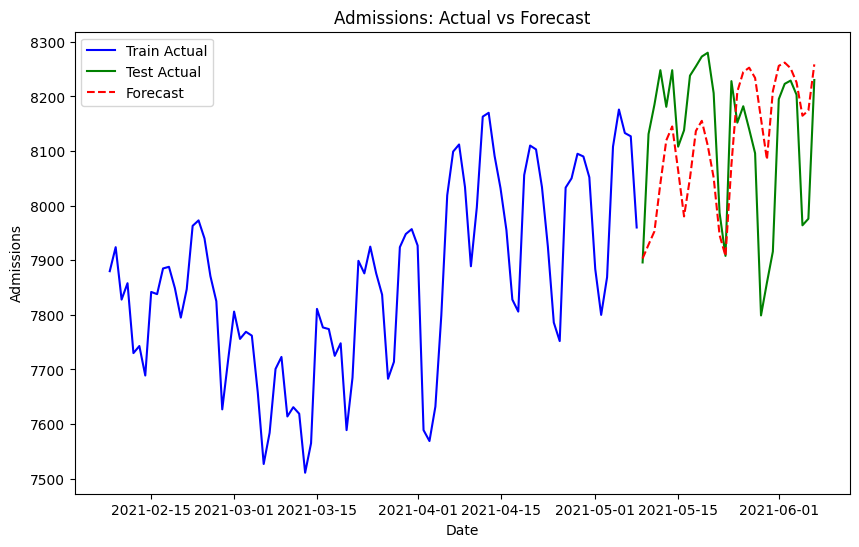

In [ ]:
#| hide

from peshbeen.datasets import load_admission_calls
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from cubist import Cubist

## get day of week and month as features from the date index
load_admission_calls["day_of_week"] = load_admission_calls.index.dayofweek
load_admission_calls["month"] = load_admission_calls.index.month
train = load_admission_calls[:-30]
test = load_admission_calls[-30:]

cat_variables = ["day_of_week", "month"]
ml_linear = ml_mv_forecaster(model=LGBMRegressor(verbose=-1),
              target_cols=['admissions', "calls"], lags = {"admissions": 7, "calls": 7},
                cat_variables=cat_variables,
                trend={"admissions": "linear", "calls": "linear"}, change_points={"admissions": [100], "calls": [130]}, pol_degree={"admissions": 1, "calls": 1})
ml_linear.fit(train)
forecasts = ml_linear.forecast(H=30, exog=test[cat_variables])

# plot actual vs forecasted for both targets
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train Actual', color='blue')
plt.plot(test.index, test['admissions'], label='Test Actual', color='green')
plt.plot(test.index, forecasts['admissions'], label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('Admissions: Actual vs Forecast')
plt.legend()
plt.show()

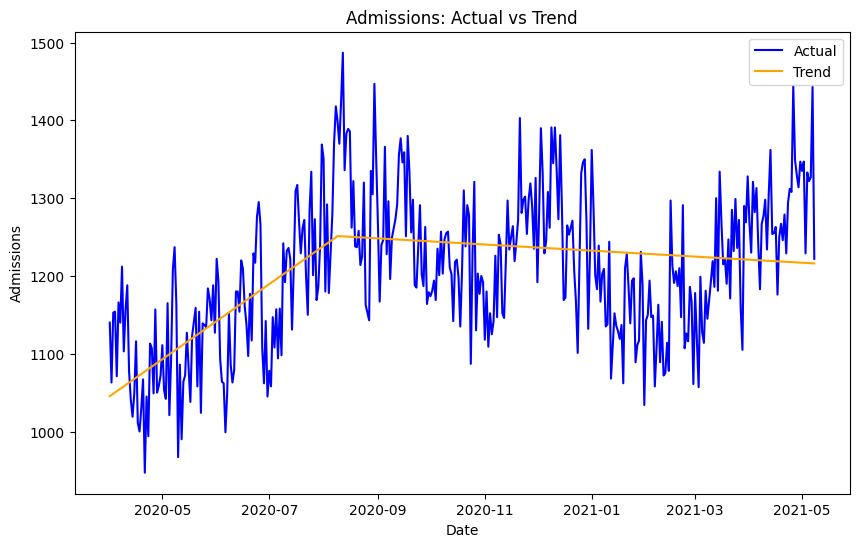

In [ ]:
#| hide
trn, mld, X_tr = lr_trend_model(train['calls'], breakpoints=[130], type='piecewise', degree=1)
# plot actual vs trend for admissions
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['calls'], label='Actual', color='blue')
plt.plot(train.index, trn, label='Trend', color='orange')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('Admissions: Actual vs Trend')
plt.legend()
plt.show()

In [ ]:
#| hide

from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
perform, cvdf = ml_linear.cross_validate(df=load_admission_calls, target_col='calls', cv_split=3, test_size=30, metrics=mtrcs, h_split_point=15, cv_df=True)